In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("sales_and_customer_insights.csv")

In [5]:

print(df.head(10))

   Customer_ID   Product_ID Transaction_ID  Purchase_Frequency  \
0  CUST_9HOS83  PROD_IK97D1   TRANS_II1DZG                  17   
1  CUST_AJU17N  PROD_UNN7KP   TRANS_9HJF7I                  10   
2  CUST_11XNYF  PROD_0XEW2W   TRANS_OT96OM                   3   
3  CUST_IGH8G3  PROD_3IIAJN   TRANS_45V00G                  12   
4  CUST_OK6PUM  PROD_VMIWD2   TRANS_ZAK760                  18   
5  CUST_63F5GB  PROD_L0NAD5   TRANS_HI4MBV                  12   
6  CUST_P9K9F2  PROD_CVVCB0   TRANS_X0MXCI                  16   
7  CUST_EMHZQV  PROD_PVOV5L   TRANS_9B8B46                  10   
8  CUST_8E2Q1K  PROD_MG36BV   TRANS_AZ1OW8                   7   
9  CUST_4VB1T5  PROD_DKK6UZ   TRANS_AC3353                   6   

   Average_Order_Value Most_Frequent_Category  Time_Between_Purchases  \
0               172.57            Electronics                      45   
1                64.89               Clothing                       6   
2               120.38                 Sports         

In [6]:
print(df.shape)

(10000, 15)


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               10000 non-null  object 
 1   Product_ID                10000 non-null  object 
 2   Transaction_ID            10000 non-null  object 
 3   Purchase_Frequency        10000 non-null  int64  
 4   Average_Order_Value       10000 non-null  float64
 5   Most_Frequent_Category    10000 non-null  object 
 6   Time_Between_Purchases    10000 non-null  int64  
 7   Region                    10000 non-null  object 
 8   Churn_Probability         10000 non-null  float64
 9   Lifetime_Value            10000 non-null  float64
 10  Launch_Date               10000 non-null  object 
 11  Peak_Sales_Date           10000 non-null  object 
 12  Season                    10000 non-null  object 
 13  Preferred_Purchase_Times  10000 non-null  object 
 14  Retenti

In [8]:
print(df.isnull().sum())

Customer_ID                 0
Product_ID                  0
Transaction_ID              0
Purchase_Frequency          0
Average_Order_Value         0
Most_Frequent_Category      0
Time_Between_Purchases      0
Region                      0
Churn_Probability           0
Lifetime_Value              0
Launch_Date                 0
Peak_Sales_Date             0
Season                      0
Preferred_Purchase_Times    0
Retention_Strategy          0
dtype: int64


In [9]:
# Fill numeric columns
df['Average_Order_Value'] = df['Average_Order_Value'].fillna(df['Average_Order_Value'].mean())

df['Purchase_Frequency'] = df['Purchase_Frequency'].fillna(df['Purchase_Frequency'].median())

In [10]:
print(df['Region'].head())

0    South America
1    South America
2             Asia
3    North America
4    North America
Name: Region, dtype: object


In [11]:
print(df['Region'].isnull().sum())

0


In [12]:
print(df['Region'].value_counts())

Region
Europe           2547
South America    2527
Asia             2472
North America    2454
Name: count, dtype: int64


In [13]:
if df['Region'].mode().empty:
    df['Region'] = df['Region'].fillna("Unknown")
else:
    df['Region'] = df['Region'].fillna(df['Region'].mode()[0])

In [14]:
df = df.drop_duplicates()

In [15]:
print(df.duplicated().sum())

0


In [16]:
df['Launch_Date'] = pd.to_datetime(df['Launch_Date'], errors='coerce')
df['Peak_Sales_Date'] = pd.to_datetime(df['Peak_Sales_Date'], errors='coerce')

In [17]:
df.head()

,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,Season,Preferred_Purchase_Times,Retention_Strategy
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,2020-03-14,2023-09-11,Winter,Afternoon,Loyalty Program
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,2022-10-15,2023-01-02,Spring,Afternoon,Discount
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,2021-11-30,2023-04-06,Winter,Evening,Loyalty Program
3,CUST_IGH8G3,PROD_3IIAJN,TRANS_45V00G,12,70.34,Clothing,5,North America,0.78,4880.01,2022-03-20,2023-03-23,Spring,Evening,Discount
4,CUST_OK6PUM,PROD_VMIWD2,TRANS_ZAK760,18,42.39,Electronics,10,North America,0.52,8557.70,2022-11-09,2023-10-28,Spring,Morning,Discount


In [18]:
# Remove extra spaces & standardize
df['Region'] = df['Region'].str.strip().str.lower()

df['Most_Frequent_Category'] = df['Most_Frequent_Category'].str.strip().str.title()

In [19]:
df.rename(columns={
    'Average_Order_Value': 'Avg_Order_Value',
    'Purchase_Frequency': 'Purchase_Freq'
}, inplace=True)

In [20]:
# Customer lifetime days
df['Customer_Age_Days'] = (pd.Timestamp.today() - df['Launch_Date']).dt.days

# High value customer flag
df['High_Value_Customer'] = df['Lifetime_Value'].apply(lambda x: 1 if x > 5000 else 0)

In [21]:
df.head()

,Customer_ID,Product_ID,Transaction_ID,Purchase_Freq,Avg_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,Season,Preferred_Purchase_Times,Retention_Strategy,Customer_Age_Days,High_Value_Customer
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,south america,0.98,952.81,2020-03-14,2023-09-11,Winter,Afternoon,Loyalty Program,2201,0
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,south america,0.66,5427.51,2022-10-15,2023-01-02,Spring,Afternoon,Discount,1256,1
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,asia,0.60,3994.80,2021-11-30,2023-04-06,Winter,Evening,Loyalty Program,1575,0
3,CUST_IGH8G3,PROD_3IIAJN,TRANS_45V00G,12,70.34,Clothing,5,north america,0.78,4880.01,2022-03-20,2023-03-23,Spring,Evening,Discount,1465,0
4,CUST_OK6PUM,PROD_VMIWD2,TRANS_ZAK760,18,42.39,Electronics,10,north america,0.52,8557.70,2022-11-09,2023-10-28,Spring,Morning,Discount,1231,1


In [22]:
df.drop(columns=['Customer_ID'], inplace=True)  # if not needed

In [23]:
#handles outliers
df['Avg_Order_Value'] = df['Avg_Order_Value'].clip(upper=10000)

In [24]:
df.to_csv("cleaned_customer_data.csv", index=False)

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [24]:
print(df.describe())

       Purchase_Freq  Avg_Order_Value  Time_Between_Purchases  \
count   10000.000000     10000.000000            10000.000000   
mean        9.955700       110.006022               46.885300   
min         1.000000        20.010000                5.000000   
25%         5.000000        65.262500               25.000000   
50%        10.000000       109.930000               47.000000   
75%        15.000000       155.480000               68.000000   
max        19.000000       199.960000               89.000000   
std         5.526209        52.096870               24.711746   

       Churn_Probability  Lifetime_Value                 Launch_Date  \
count       10000.000000    10000.000000                       10000   
mean            0.501552     5031.930567  2021-07-01 18:07:46.560000   
min             0.000000      100.160000         2020-01-01 00:00:00   
25%             0.250000     2518.775000         2020-10-04 00:00:00   
50%             0.500000     5012.180000         2021-

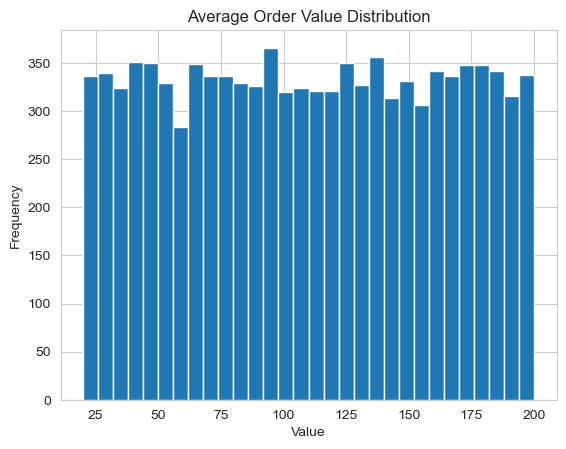

In [25]:
plt.hist(df['Avg_Order_Value'], bins=30)
plt.title("Average Order Value Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

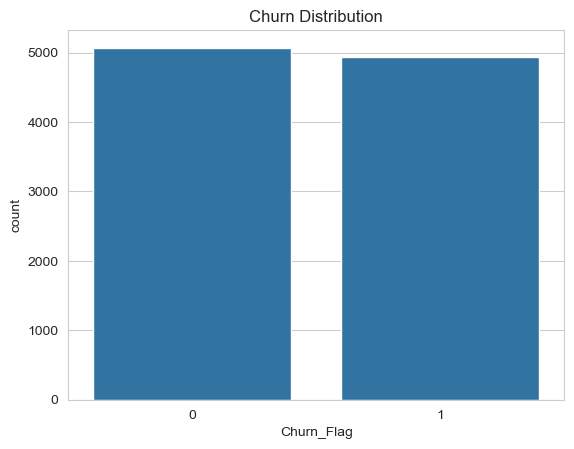

In [26]:
df['Churn_Flag'] = (df['Churn_Probability'] > 0.5).astype(int)

sns.countplot(x='Churn_Flag', data=df)
plt.title("Churn Distribution")
plt.show()

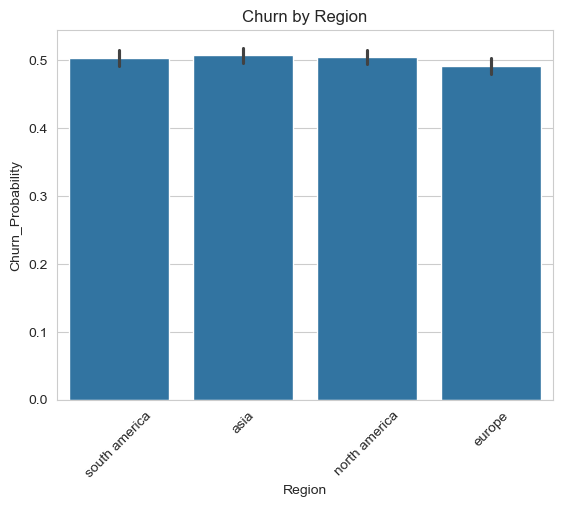

In [27]:
sns.barplot(x='Region', y='Churn_Probability', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Region")
plt.show()

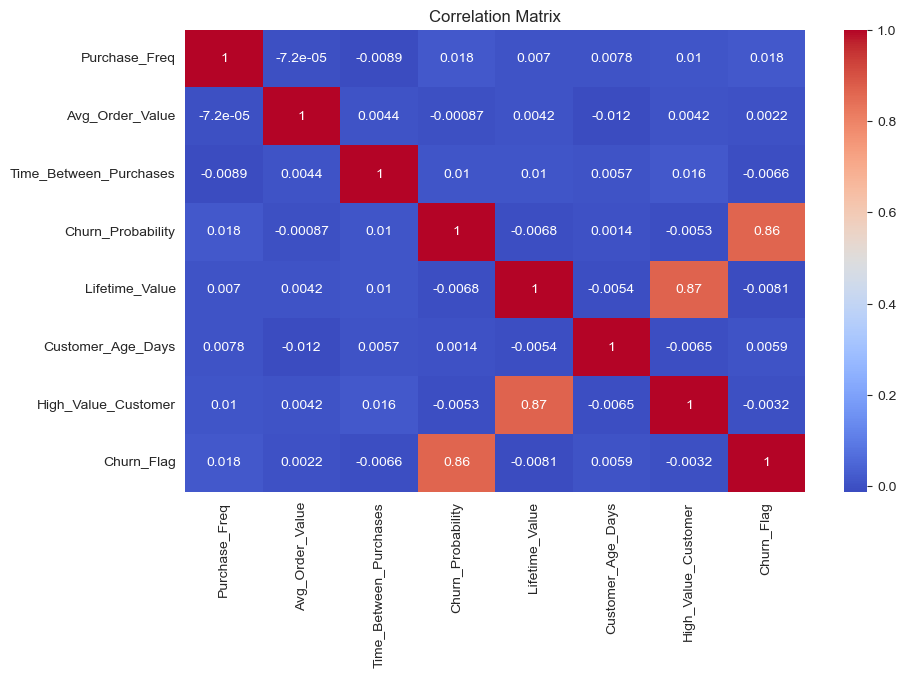

In [28]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

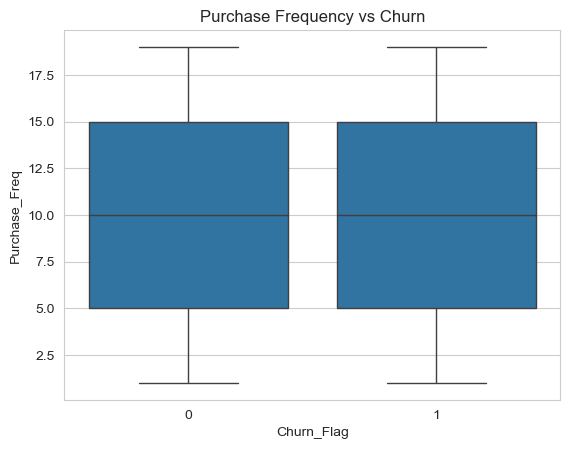

In [29]:
sns.boxplot(x='Churn_Flag', y='Purchase_Freq', data=df)
plt.title("Purchase Frequency vs Churn")
plt.show()

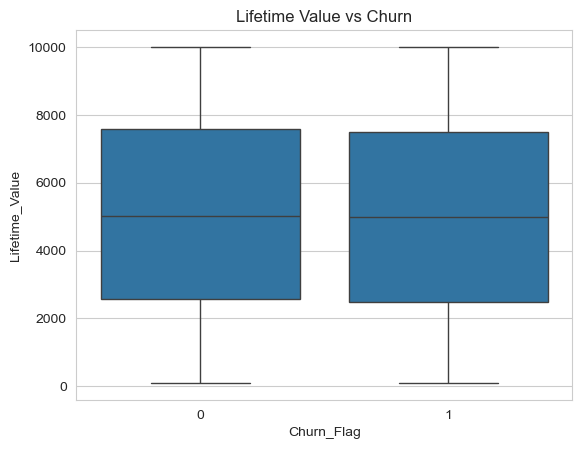

In [30]:
sns.boxplot(x='Churn_Flag', y='Lifetime_Value', data=df)
plt.title("Lifetime Value vs Churn")
plt.show()

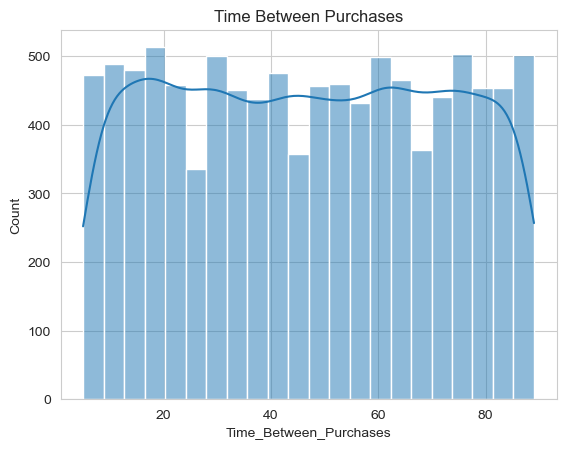

In [31]:
sns.histplot(df['Time_Between_Purchases'], kde=True)
plt.title("Time Between Purchases")
plt.show()

In [ ]:
#insights from charts
#Customers with low purchase frequency have higher churn
#Certain regions show higher churn rates
#Customers with long gaps between purchases are more likely to churn
#High lifetime value customers are more stable

In [32]:
#ML
df['Churn_Flag'] = (df['Churn_Probability'] > 0.5).astype(int) #creating a target column (churn or not):

In [33]:
#selecting features
X = df[['Purchase_Freq', 'Avg_Order_Value', 
        'Time_Between_Purchases', 'Lifetime_Value']]

y = df['Churn_Flag']

In [34]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
#Train Model (Logistic Regression)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [36]:
#Predictions
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5005
[[671 360]
 [639 330]]
              precision    recall  f1-score   support

           0       0.51      0.65      0.57      1031
           1       0.48      0.34      0.40       969

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.49      2000
weighted avg       0.50      0.50      0.49      2000



In [38]:
#Improve Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.51


In [39]:
#Feature Importance
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance) #Which factor causes churn most

                  Feature  Importance
3          Lifetime_Value    0.322043
1         Avg_Order_Value    0.315006
2  Time_Between_Purchases    0.219981
0           Purchase_Freq    0.142971


In [ ]:
#BUSINESS INSIGHT
#Customers with low purchase frequency are likely to churn
#Higher time between purchases → higher churn
#High value customers are less likely to churn

In [1]:
import os
print(os.getcwd())

C:\Users\delphy.jn


In [25]:
df.to_csv(r"C:\Users\delphy.jn\Downloads\cleaned_customer_data.csv", index=False)

In [26]:
print(df.shape)

(10000, 16)


In [27]:
df.to_csv(r"C:\Users\delphy.jn\Downloads\cleaned_customer_data.csv", index=False)

In [28]:
df.describe()

,Purchase_Freq,Avg_Order_Value,Time_Between_Purchases,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,Customer_Age_Days,High_Value_Customer
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000.000000,10000.000000
mean,9.955700,110.006022,46.885300,0.501552,5031.930567,2021-07-01 18:07:46.560000,2023-07-01 08:46:01.920000,1726.244600,0.501300
min,1.000000,20.010000,5.000000,0.000000,100.160000,2020-01-01 00:00:00,2023-01-01 00:00:00,1178.000000,0.000000
25%,5.000000,65.262500,25.000000,0.250000,2518.775000,2020-10-04 00:00:00,2023-03-31 00:00:00,1454.000000,0.000000
50%,10.000000,109.930000,47.000000,0.500000,5012.180000,2021-07-02 00:00:00,2023-07-02 00:00:00,1726.000000,1.000000
75%,15.000000,155.480000,68.000000,0.750000,7526.232500,2022-03-31 00:00:00,2023-10-01 00:00:00,1997.000000,1.000000
max,19.000000,199.960000,89.000000,1.000000,9999.760000,2023-01-01 00:00:00,2023-12-31 00:00:00,2274.000000,1.000000
std,5.526209,52.096870,24.711746,0.288289,2865.420299,NaN,NaN,315.023397,0.500023


In [30]:
df.columns

Index(['Product_ID', 'Transaction_ID', 'Purchase_Freq', 'Avg_Order_Value',
       'Most_Frequent_Category', 'Time_Between_Purchases', 'Region',
       'Churn_Probability', 'Lifetime_Value', 'Launch_Date', 'Peak_Sales_Date',
       'Season', 'Preferred_Purchase_Times', 'Retention_Strategy',
       'Customer_Age_Days', 'High_Value_Customer'],
      dtype='object')